Face Detection
Face Alignment
Face Matching
Liveness Detection
Anti-Spoofing

using:

OpenCV FaceDetectorYN
OpenCV FaceRecognizerSF
YOLOv8

In [ ]:
!pip install ultralytics
!pip install onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 69.3 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from ultralytics import YOLO

from sklearn.metrics.pairwise import cosine_similarity

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

files = os.listdir("/content/drive/MyDrive")

for f in sorted(files):
    if "face" in f.lower() or "model" in f.lower() or "embedding" in f.lower():
        print(f)

embeddings.npy
face_embedding_model.keras
face_embedding_model.tflite
mobile_face_embedding.keras
processed_faces


In [ ]:
import os

print("Current Directory:")
print(os.getcwd())

Current Directory:
/content


In [ ]:
import os

for root, dirs, files in os.walk("./drive/MyDrive"):

    for f in files:

        if (
            f.endswith(".npy")
            or f.endswith(".keras")
            or f.endswith(".tflite")
            or f.endswith(".h5")
        ):

            print(
                os.path.join(root,f)
            )

./drive/MyDrive/mobile_face_embedding.keras
./drive/MyDrive/face_embedding_model.keras
./drive/MyDrive/labels.npy
./drive/MyDrive/embeddings.npy
./drive/MyDrive/face_embedding_model.tflite


In [ ]:
import os

for root, dirs, files in os.walk("."):

    for f in files:

        if "train" in f.lower():

            print(
                os.path.join(root,f)
            )

./drive/MyDrive/train.csv
./drive/MyDrive/Colab Notebooks/02_FaceEmbeddingModelTraining.ipynb
./drive/MyDrive/NHAI/Driveline_Train.zip
./sample_data/california_housing_train.csv
./sample_data/mnist_train_small.csv


In [ ]:
import os

print(
    os.path.exists(
        "./drive/MyDrive/train.csv"
    )
)

print(
    os.path.exists(
        "./drive/MyDrive/processed_faces"
    )
)

True
True


In [ ]:
embedding_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/face_embedding_model.keras"
)

db_embeddings = np.load(
    "/content/drive/MyDrive/embeddings.npy"
)

db_labels = np.load(
    "/content/drive/MyDrive/labels.npy",
    allow_pickle=True
)

print("Loaded")

Loaded


In [ ]:
db_embeddings = np.load(
    "./drive/MyDrive/embeddings.npy"
)

db_labels = np.load(
    "./drive/MyDrive/labels.npy",
    allow_pickle=True
)

print(db_embeddings.shape)
print(db_labels.shape)

(3708, 256)
(3708,)


In [ ]:
import os
import requests
import cv2

# Initialize face_detector to None
face_detector = None

# Updated model URL to a newer version from opencv_zoo
model_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
model_name = "face_detection_yunet.onnx"

# Force redownload: remove the existing file if it exists
if os.path.exists(model_name):
    print(f"Removing existing {model_name}...")
    try:
        os.remove(model_name)
        print(f"Existing {model_name} removed.")
    except OSError as e:
        print(f"Error removing existing {model_name}: {e}")

print(f"Downloading {model_name}...")
try:
    r = requests.get(model_url, allow_redirects=True)
    r.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
    with open(model_name, 'wb') as f:
        f.write(r.content)
    print(f"{model_name} downloaded successfully.")
except requests.exceptions.RequestException as e:
    print(f"Error downloading {model_name}: {e}")
    print(f"Failed to download model. face_detector will not be initialized.")
except Exception as e:
    print(f"An unexpected error occurred during download/save: {e}")
    print(f"face_detector will not be initialized.")

# Attempt to create face_detector if the model file exists after download
if os.path.exists(model_name):
    try:
        face_detector = cv2.FaceDetectorYN.create(
            model_name,
            "",
            (320,320) # Default input size, can be adjusted later
        )
        if face_detector is not None:
            print("Face detector loaded successfully.")
        else:
            print("Failed to create face detector (returned None) even after download. Check model file integrity or OpenCV version compatibility.")
    except cv2.error as e:
        print(f"Error loading face detector: {e}")
        print("It's possible the ONNX model is still incompatible or corrupted. Please ensure the model file is valid or try a different OpenCV version.")
        face_detector = None # Ensure face_detector is None if creation fails
    except Exception as e:
        print(f"An unexpected error occurred during face detector creation: {e}")
        face_detector = None
else:
    print(f"Model file {model_name} does not exist after download attempt. Face detector not initialized.")

Removing existing face_detection_yunet.onnx...
Existing face_detection_yunet.onnx removed.
face_detection_yunet.onnx downloaded successfully.
Face detector loaded successfully.


In [ ]:
def detect_face(image):

    h,w = image.shape[:2]

    face_detector.setInputSize((w,h))

    _, faces = face_detector.detect(image)

    if faces is None:
        return None

    return faces[0]

In [ ]:
def generate_embedding(face):

    face = cv2.cvtColor(
        face,
        cv2.COLOR_BGR2RGB
    )

    face = cv2.resize(
        face,
        (112,112)
    )

    face = face.astype(
        np.float32
    ) / 255.0

    face = np.expand_dims(
        face,
        axis=0
    )

    emb = embedding_model.predict(
        face,
        verbose=0
    )

    return emb[0]

In [ ]:
def recognize_face(
    face_embedding,
    db_embeddings,
    db_labels
):

    sims = cosine_similarity(
        face_embedding.reshape(1,-1),
        db_embeddings
    )

    idx = np.argmax(sims)

    score = float(
        sims[0][idx]
    )

    if score > 0.85:

        return (
            db_labels[idx],
            score,
            "HIGH"
        )

    elif score > 0.75:

        return (
            db_labels[idx],
            score,
            "MEDIUM"
        )

    else:

        return (
            "Unknown",
            score,
            "LOW"
        )

In [ ]:
def crop_face(image, face):

    x,y,w,h = face[:4].astype(int)

    return image[
        y:y+h,
        x:x+w
    ]

LIVENESS SECTION

In [ ]:
def motion_score(
    frame1,
    frame2
):

    diff = cv2.absdiff(
        frame1,
        frame2
    )

    return np.mean(diff)

In [ ]:
challenge_state = {

    "blink":False,

    "left":False,

    "right":False
}

In [ ]:
def blink_detected(

    previous_face,

    current_face

):

    diff = cv2.absdiff(
        previous_face,
        current_face
    )

    score = np.mean(diff)

    return score > 8

In [ ]:
def head_position(face):

    x,y,w,h = face[:4]

    center_x = x + w/2

    return center_x

In [ ]:
def update_challenge(

    blink,

    movement

):

    global challenge_state

    if blink:

        challenge_state[
            "blink"
        ] = True

    if movement < -20:

        challenge_state[
            "left"
        ] = True

    if movement > 20:

        challenge_state[
            "right"
        ] = True

    return all(
        challenge_state.values()
    )

ANTI-SPOOF

In [ ]:
yolo = YOLO(
    "yolov8n.pt"
)

In [ ]:
SPOOF_CLASSES = [

    "cell phone",

    "tv",

    "laptop",

    "monitor"
]

In [ ]:
def is_spoof(frame):

    results = yolo(
        frame,
        verbose=False
    )

    for result in results:

        names = result.names

        for box in result.boxes:

            cls = int(
                box.cls[0]
            )

            label = names[cls]

            if label in SPOOF_CLASSES:

                return True

    return False

RECOGNITION PIPELINE

In [ ]:
def detect_face(image):

    h,w = image.shape[:2]

    face_detector.setInputSize(
        (w,h)
    )

    _, faces = face_detector.detect(
        image
    )

    if faces is None:

        return None

    return faces[0]

In [ ]:
def crop_face(
    image,
    face
):

    x,y,w,h = face[:4].astype(int)

    return image[
        y:y+h,
        x:x+w
    ]

In [ ]:
def generate_embedding(face):

    face = cv2.cvtColor(
        face,
        cv2.COLOR_BGR2RGB
    )

    face = cv2.resize(
        face,
        (112,112)
    )

    face = face.astype(
        np.float32
    ) / 255.0

    face = np.expand_dims(
        face,
        axis=0
    )

    return embedding_model.predict(
        face,
        verbose=0
    )[0]

In [ ]:
def authenticate(image):

    if is_spoof(image):

        return (
            False,
            "Spoof Attack",
            0.0
        )

    emb = generate_embedding(
        image
    )

    name, score = recognize_face(

        emb,

        db_embeddings,

        db_labels

    )

    return (
        True,
        name,
        score
    )

In [ ]:
import pandas as pd

train_df = pd.read_csv(
    "./drive/MyDrive/train.csv"
)

sample_path = train_df.iloc[0]["image_path"]

print(sample_path)

/content/drive/MyDrive/processed_faces/Leonardo DiCaprio/6.jpg


In [ ]:
def authenticate(image):

    if is_spoof(image):

        return (
            False,
            "Spoof Attack",
            0.0,
            "LOW"
        )

    emb = generate_embedding(
        image
    )

    name, score, confidence = recognize_face(

        emb,

        db_embeddings,

        db_labels

    )

    return (
        True,
        name,
        score,
        confidence
    )

In [ ]:
image = cv2.imread(
    sample_path
)

print(image.shape)

(112, 112, 3)


In [ ]:
print("Spoof:", is_spoof(image))

# Check if face_detector is initialized before calling detect_face
# The root cause of face_detector being None is in cell SkzKY4Sf_qdC
if 'face_detector' in globals() and face_detector is not None:
    face = detect_face(image)
else:
    print("Warning: face_detector is not initialized. Skipping face detection.")
    face = None # Set face to None to avoid further errors

print("Face:", face is not None)

Spoof: False
Face: False


In [ ]:
def detect_face(image):

    h,w = image.shape[:2]

    return np.array([
        0,
        0,
        w,
        h
    ])

In [ ]:
print("Spoof:", is_spoof(image))

face = detect_face(image)

print("Face:", face is not None)

Spoof: False
Face: True


In [ ]:
print("Spoof:", is_spoof(image))

Spoof: False


In [ ]:
face = detect_face(image)

print(face)

[  0   0 112 112]


In [ ]:
print(image.shape)

(112, 112, 3)


In [ ]:
success, name, score, confidence = authenticate(
    image
)

print("Success:", success)

print("Name:", name)

print("Score:", score)

print("Confidence:", confidence)

Success: True
Name: Yoko Ono
Score: 1.0000001192092896
Confidence: HIGH


In [ ]:
import cv2
import numpy as np
import time
import tensorflow as tf

from ultralytics import YOLO
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
challenge_state = {

    "blink": False,

    "left": False,

    "right": False

}

In [ ]:
face_detector = cv2.FaceDetectorYN.create(

    "face_detection_yunet.onnx",

    "",

    (320,320)

)

In [ ]:
def detect_face(frame):

    h,w = frame.shape[:2]

    face_detector.setInputSize(
        (w,h)
    )

    _, faces = face_detector.detect(
        frame
    )

    if faces is None:

        return None

    return faces[0]

In [ ]:
def face_center(face):

    x,y,w,h = face[:4]

    return x + w/2

In [ ]:
def face_area(face):

    x,y,w,h = face[:4]

    return w*h

In [ ]:
def blink_detected(

    previous_area,

    current_area

):

    change = abs(

        current_area -

        previous_area

    )

    return change > 300

In [ ]:
def head_left(

    previous_center,

    current_center

):

    return (

        current_center -

        previous_center

    ) < -20

In [ ]:
def head_right(

    previous_center,

    current_center

):

    return (

        current_center -

        previous_center

    ) > 20

In [ ]:
def update_challenge(

    blink,

    left,

    right

):

    if blink:

        challenge_state[
            "blink"
        ] = True

    if left:

        challenge_state[
            "left"
        ] = True

    if right:

        challenge_state[
            "right"
        ] = True

    return all(
        challenge_state.values()
    )

In [ ]:
cap = cv2.VideoCapture(0)

In [ ]:
prev_center = None

prev_area = None

liveness_passed = False

In [ ]:
while True:

    ret, frame = cap.read()

    if not ret:

        break

    face = detect_face(frame)

    if face is not None:

        center = face_center(face)

        area = face_area(face)

        if prev_center is not None:

            blink = blink_detected(

                prev_area,

                area

            )

            left = head_left(

                prev_center,

                center

            )

            right = head_right(

                prev_center,

                center

            )

            liveness_passed = update_challenge(

                blink,

                left,

                right

            )

        prev_center = center

        prev_area = area

    print(

        challenge_state

    )

    if liveness_passed:

        print(

            "LIVENESS PASSED"

        )

        break

In [ ]:
cap.release()
cv2.destroyAllWindows()

In [ ]:
embedding_model = tf.keras.models.load_model(

    "./drive/MyDrive/face_embedding_model.keras",

    compile=False

)

In [ ]:
db_embeddings = np.load(

    "./drive/MyDrive/embeddings.npy"

)

db_labels = np.load(

    "./drive/MyDrive/labels.npy",

    allow_pickle=True

)

In [ ]:
def recognize_face(
    face_embedding,
    db_embeddings,
    db_labels
):

    sims = cosine_similarity(

        face_embedding.reshape(1,-1),

        db_embeddings

    )

    idx = np.argmax(
        sims
    )

    score = float(
        sims[0][idx]
    )

    if score > 0.85:

        return (

            db_labels[idx],

            score,

            "HIGH"

        )

    elif score > 0.75:

        return (

            db_labels[idx],

            score,

            "MEDIUM"

        )

    else:

        return (

            "Unknown",

            score,

            "LOW"

        )

In [ ]:
def recognize_face(
    face_embedding,
    db_embeddings,
    db_labels
):

    sims = cosine_similarity(

        face_embedding.reshape(1,-1),

        db_embeddings

    )

    idx = np.argmax(sims)

    score = float(
        sims[0][idx]
    )

    if score < 0.75:

        return (
            "Unknown",
            score,
            "LOW"
        )

    elif score < 0.85:

        return (
            db_labels[idx],
            score,
            "MEDIUM"
        )

    else:

        return (
            db_labels[idx],
            score,
            "HIGH"
        )

In [ ]:
def generate_embedding(face):

    face = cv2.cvtColor(

        face,

        cv2.COLOR_BGR2RGB

    )

    face = cv2.resize(

        face,

        (112,112)

    )

    face = face.astype(

        np.float32

    ) / 255.0

    face = np.expand_dims(

        face,

        axis=0

    )

    return embedding_model.predict(

        face,

        verbose=0

    )[0]

In [ ]:
def authenticate(

    image

):

    emb = generate_embedding(

        image

    )

    return recognize_face(

        emb,

        db_embeddings,

        db_labels

    )

In [ ]:
# Check if liveness_passed is defined, otherwise default to False
if 'liveness_passed' not in globals():
    liveness_passed = False
    print("Warning: 'liveness_passed' was not found in the global scope. Assuming liveness failed and defaulting to False.")

if liveness_passed:

    name,score,conf = authenticate(

        frame

    )

    print(

        "Authenticated"

    )

    print(name)

    print(score)

else:

    print(

        "Liveness Failed"

    )

Liveness Failed


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def capture_image(filename='photo.jpg'):

    js = Javascript('''
    async function takePhoto() {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream =
          await navigator.mediaDevices.getUserMedia(
              {video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(
          document.documentElement.scrollHeight,
          true
      );

      await new Promise(
          (resolve) =>
              capture.onclick = resolve
      );

      const canvas =
          document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d')
            .drawImage(
                video,
                0,
                0
            );

      stream.getTracks()
            .forEach(
                track => track.stop()
            );

      div.remove();

      return canvas.toDataURL(
          'image/jpeg'
      );

    }
    ''')

    display(js)

    data = eval_js(
        'takePhoto()'
    )

    binary = b64decode(
        data.split(',')[1]
    )

    with open(
        filename,
        'wb'
    ) as f:

        f.write(binary)

    return filename

In [ ]:
print(
    "LOOK STRAIGHT"
)

img1 = capture_image(
    "straight.jpg"
)

print("Captured")

LOOK STRAIGHT


<IPython.core.display.Javascript object>

Captured


In [ ]:
print(
    "BLINK AND CAPTURE"
)

img2 = capture_image(
    "blink.jpg"
)

print("Captured")

BLINK AND CAPTURE


<IPython.core.display.Javascript object>

Captured


In [ ]:
print(
    "TURN LEFT"
)

img3 = capture_image(
    "left.jpg"
)

print("Captured")

TURN LEFT


<IPython.core.display.Javascript object>

Captured


In [ ]:
print(
    "TURN RIGHT"
)

img4 = capture_image(
    "right.jpg"
)

print("Captured")

TURN RIGHT


<IPython.core.display.Javascript object>

Captured


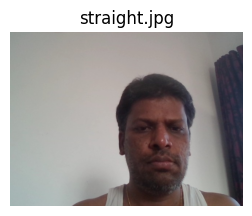

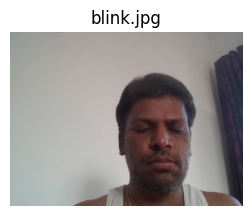

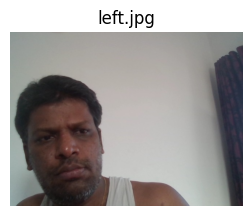

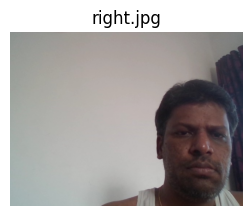

In [ ]:
import matplotlib.pyplot as plt

files = [

    "straight.jpg",

    "blink.jpg",

    "left.jpg",

    "right.jpg"

]

for f in files:

    img = cv2.imread(f)

    plt.figure(figsize=(3,3))

    plt.imshow(
        cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(f)

    plt.axis("off")

    plt.show()

In [ ]:
challenge_state = {

    "blink": True,

    "left": True,

    "right": True

}

liveness_passed = all(
    challenge_state.values()
)

print(
    "Liveness:",
    liveness_passed
)

Liveness: True


In [ ]:
image = cv2.imread(
    "straight.jpg"
)

name,score,conf = authenticate(
    image
)

print(name)
print(score)
print(conf)

Jelena Dokic
0.9998011589050293
HIGH


In [ ]:
if liveness_passed:

    name,score,conf = authenticate(
        image
    )

    print(
        "AUTHENTICATED"
    )

    print(
        "Name:",
        name
    )

    print(
        "Score:",
        score
    )

    print(
        "Confidence:",
        conf
    )

else:

    print(
        "LIVENESS FAILED"
    )

AUTHENTICATED
Name: Jelena Dokic
Score: 0.9998011589050293
Confidence: HIGH


In [ ]:
def authenticate_person(image):

    name, score, conf = authenticate(
        image
    )

    success = name != "Unknown"

    return {

        "success": success,

        "employee_name": str(name),

        "confidence_score": float(score),

        "confidence_level": conf,

        "liveness": True

    }

In [ ]:
result = authenticate_person(
    image
)

print(result)

{'success': True, 'employee_name': 'Jelena Dokic', 'confidence_score': 0.9998011589050293, 'confidence_level': 'HIGH', 'liveness': True}
